In [1]:
import torch
from visual_autolabel.image._model import HybridUNet
from pathlib import Path
import numpy as np

In [84]:
inputs3D = ('graymask', 'T1', 'T2')
inputs2D = ('curvature', 'convexity', 'thickness')
outputs = ('V1', 'V2', 'V3')

In [85]:
model = HybridUNet(len(inputs3D), len(inputs3D), len(inputs2D), len(outputs))

In [ ]:
ckpt = torch.load(
    #"/data/visual-autolabel/models/best_hybrid_weights.pt",
    "/data/visual-autolabel/models/hybrid_lr0.0010820864449838253_gamma0.8085398447864768_bs8_loss0.19568892568349838.pt",
    map_location="cpu",
    weights_only=True)
model.load_state_dict(ckpt)

In [86]:
import visual_autolabel as val

dataset2D_cache_path = '/data/visual-autolabel/datasets/HCP'
tx3Dto2D_cache_path = '/data/visual-autolabel/volumetric/data/tx3Dto2D'

val.image.dataset3D_cache_path = '/data/visual-autolabel/volumetric/data'
val.image.noddi_data_path = '/data/visual-autolabel/volumetric/NODDI'

In [87]:
class VolumeToFlatImageDataset(torch.utils.data.Dataset):
    def __init__(self,
                 sids,
                 cache_path=tx3Dto2D_cache_path):
        self.cache_path = Path(cache_path)
        self.sids = sids
        self.data = {}
    def __len__(self):
        return len(self.sids)
    def __getitem__(self, k):
        sid = self.sids[k]
        if sid in self.data:
            return self.data[sid]
        matrix = torch.load(f"{self.cache_path}/{sid}.pt", weights_only=False)
        import scipy.sparse as sps
        (row, col, val) = sps.find(matrix)
        matrix = torch.sparse_coo_tensor(
            torch.as_tensor(np.array([row, col])),
            torch.as_tensor(val),
            matrix.shape,
            dtype=torch.float32)
        #matrix = torch.tensor(matrix, dtype=torch.float32)
        self.data[sid] = matrix
        return matrix
        
class HCPHybridDataset(torch.utils.data.Dataset):
    def __init__(self,
                 sids,
                 inputs2D,
                 inputs3D,
                 outputs=('V1', 'V2', 'V3'),
                 cache_path2D=None,
                 cache_path3D=None,
                 transform_cache_path=tx3Dto2D_cache_path,
                 dtype=None,
                 device=None,
                 mkdir_mode=509,
                 subindex=(slice(2, -2, None), slice(8, 264, None), slice(2, -2, None)),
                 zoom=0.5,
                 ):
        self.transform_dataset = VolumeToFlatImageDataset(sids, cache_path=transform_cache_path)
        self.dataset3D = val.image.HCPDataset3D(
            sids=sids,
            inputs=inputs3D,
            outputs=outputs,
            cache_path=cache_path3D,
            dtype=dtype,
            device=device,
            mkdir_mode=0o775,
            subindex=subindex,
            zoom=zoom)
        self.dataset2D = val.benson2025.hcp.HCPDataset(
            inputs2D,
            outputs,
            sids=sids,
            cache_path=cache_path2D)
        self.sids = sids
    def __len__(self):
        return len(self.sids)
    def __getitem__(self, k):
        inputdata3D, _ = self.dataset3D[k]
        transformdata3D = self.transform_dataset[k]
        inputdata2D, outputdata2D = self.dataset2D[k]
        return (inputdata3D, transformdata3D, inputdata2D, outputdata2D)

def hybrid_collate(batch):
    inputs3D, transforms, inputs2D, labels = zip(*batch)
    return (
        torch.stack(inputs3D),   
        list(transforms),      
        torch.stack(inputs2D),  
        torch.stack(labels)      
    )

In [88]:
val_sids = [765864, 209228, 134829, 585256, 901442, 169444, 380036, 389357,
            581450, 198653, 115017, 782561, 176542, 246133, 185442, 601127,
            204521, 195041, 182739, 212419, 263436, 320826, 825048, 192641,
            360030, 177140, 146735, 126426, 789373, 871762, 172130, 171633]

ds = HCPHybridDataset(
    sids=val_sids,
    inputs2D=inputs2D,              
    inputs3D=inputs3D,             
    outputs=outputs,                
    cache_path2D=dataset2D_cache_path,
    cache_path3D=val.image.dataset3D_cache_path,
    transform_cache_path=tx3Dto2D_cache_path,
)

In [94]:
ds.dataset3D.data

lmap({192641: <lazy>, 901442: <lazy>, 212419: <lazy>, 380036: <lazy>, 115017: (tensor([[[[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          ...,
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00]],

         [[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+

In [89]:
results = []
for subno in range(len(ds)):
    print('.', end=None)
    data3D, sparse_tx, data2D, label = ds[subno]

    if data3D.dim()==4: 
        data3D = data3D.unsqueeze(0)
    if data2D.dim()==3: 
        data2D = data2D.unsqueeze(0)

    tx_list = [sparse_tx] 

    device = next(model.parameters()).device
    data3D  = data3D.to(device, dtype=torch.float32)
    data2D  = data2D.to(device, dtype=torch.float32)
    tx_list = [t.to(device) for t in tx_list]

    with torch.no_grad():
        pred = model(data3D, data2D, tx_list)
        pred = torch.sigmoid(pred)
        pred_label = torch.argmax(pred[0], axis=0) + 1
        pred_label[torch.max(pred[0], axis=0).values < 0.5] = 0
    tmp = (
        val.util.bce_loss(pred, label[None,...]),
        val.util.dice_loss(pred, label[None,...]))
    print(tmp)
    results.append(tmp)

print("pred:", pred.shape)

.
(tensor(1.9583), tensor(0.9142))
.
(tensor(1.9617), tensor(0.9132))
.
(tensor(1.9523), tensor(0.9067))
.
(tensor(1.9593), tensor(0.9052))
.


KeyboardInterrupt: 

In [78]:
results

[(tensor(2.1339), tensor(0.9186)),
 (tensor(2.1338), tensor(0.9173)),
 (tensor(2.1309), tensor(0.9115)),
 (tensor(2.1297), tensor(0.9099)),
 (tensor(2.1290), tensor(0.9081)),
 (tensor(2.1288), tensor(0.9086)),
 (tensor(2.1229), tensor(0.9012)),
 (tensor(2.1285), tensor(0.9101)),
 (tensor(2.1214), tensor(0.8992)),
 (tensor(2.1238), tensor(0.9026)),
 (tensor(2.1236), tensor(0.9008)),
 (tensor(2.1138), tensor(0.8887)),
 (tensor(2.1446), tensor(0.9307)),
 (tensor(2.1347), tensor(0.9161)),
 (tensor(2.1311), tensor(0.9128)),
 (tensor(2.1273), tensor(0.9070)),
 (tensor(2.1329), tensor(0.9135)),
 (tensor(2.1349), tensor(0.9164)),
 (tensor(2.1197), tensor(0.8969)),
 (tensor(2.1336), tensor(0.9164)),
 (tensor(2.1275), tensor(0.9068)),
 (tensor(2.1267), tensor(0.9055)),
 (tensor(2.1213), tensor(0.8997)),
 (tensor(2.1290), tensor(0.9096)),
 (tensor(2.1285), tensor(0.9086)),
 (tensor(2.1322), tensor(0.9137)),
 (tensor(2.1276), tensor(0.9073)),
 (tensor(2.1270), tensor(0.9054)),
 (tensor(2.1361), te

In [72]:
pred.shape

torch.Size([1, 3, 128, 256])

In [71]:
pred_label.shape

torch.Size([128, 256])

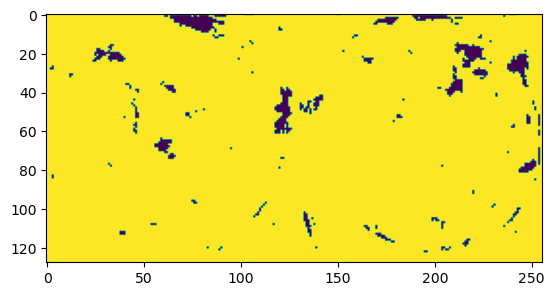

In [61]:
import matplotlib.pyplot as plt

plt.imshow(pred_label)